### DATA EDA

#### Train 데이터 불러오기

In [56]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

train_data_path ="data/train.csv"
train_data = pd.read_csv(train_data_path)

In [45]:
pd.set_option('display.max_colwidth', None)
train_data.head(5)

,idx,class,conversation
0,0,협박 대화,지금 너 스스로를 죽여달라고 애원하는 것인가?\n 아닙니다. 죄송합니다.\n 죽을 거면 혼자 죽지 우리까지 사건에 휘말리게 해? 진짜 죽여버리고 싶게.\n 정말 잘못했습니다.\n 너가 선택해. 너가 죽을래 네 가족을 죽여줄까.\n 죄송합니다. 정말 잘못했습니다.\n 너에게는 선택권이 없어. 선택 못한다면 너와 네 가족까지 모조리 죽여버릴거야.\n 선택 못하겠습니다. 한번만 도와주세요.\n 그냥 다 죽여버려야겠군. 이의 없지?\n 제발 도와주세요.
1,1,협박 대화,길동경찰서입니다.\n9시 40분 마트에 폭발물을 설치할거다.\n네?\n똑바로 들어 한번만 더 얘기한다.\n장난전화 걸지 마시죠. \n9시 40분 마트에 폭발물이 터지면 다 죽는거야. \n장난전화는 업무방해죄에 해당됩니다.\n판단은 너에게 달려있다. 길동경찰서에도 폭발물 터지면 꽤나 재미있겠지.\n선생님 진정하세요.\n난 이야기했어. 경고했다는 말이야.
2,2,기타 괴롭힘 대화,너 되게 귀여운거 알지? 나보다 작은 남자는 첨봤어.\n그만해. 니들 놀리는거 재미없어.\n지영아 너가 키 160이지? 그럼 재는 160도 안돼는거네?\n너 군대도 안가고 좋겠다.\n니들이 나 작은데 보태준거 있냐?\n난쟁이들도 장가가고하던데. 너도 희망을 가져봐 \n더이상 하지마라. \n그 키크는 수술도 있대잖아? 니네 엄마는 그거 안해주디?\n나람 해줬어. 저 키로 어찌살아.\n제발 그만 괴롭히라고!
3,3,갈취 대화,어이 거기\n예??\n너 말이야 너. 이리 오라고\n무슨 일.\n너 옷 좋아보인다?\n얘 돈 좀 있나봐\n아니에요.돈 없어요\n뒤져서 나오면 넌 죽는다\n오늘 피시방 콜?\n콜. 마지막 기회다. 있는거 다 내놔\n정말 없어요
4,4,갈취 대화,저기요 혹시 날이 너무 뜨겁잖아요? 저희 회사에서 이 선크림 파는데 한 번 손등에 발라보실래요?\n아 진짜요? 안 그래도 선크림 필요해서 알아보던 중인데 한 번 발라 볼게요!\n여기 한 번 발라보세요. 진짜 성분도 좋고 다 좋아요.\n음. 성분이 좋다고 하셔서 좋은거 같기는 한데 제 피부에 맞지 않나봐요. 피부가 따끔거리네요.\n이번에 진짜 열심히 연구해서 만든건데 피부가 많이 예민하신가봐요.\n네 많이 예민해요. 그럼 많이 파시고 안녕히 계세요.\n아니 저기요 돈 안내요?\n네? 발라보는것도 돈 내야 하나요?\n그럼 이거 누구한테 팔아요? 당신이 바른거를?\n아니 먼저 발라 보시라고 하셨잖아요. 먼저 권유해놓고 사라고 강매하는거 갈취인거 몰라요?\n내가 안 사도 된다고 말 한 적 있어? 그것도 모르고 바른걸 누구 탓 하나? 빨리 사 당신이 바른거 당신이 사야지\n진짜 어이가 없어서 다른 사람들한텐 이렇게 갈취하지마세요. 화딱지나네


--- [Class Distribution] ---
Other Abuse         : 1094 (27.70%)
Extortion           : 981 (24.84%)
Workplace Abuse     : 979 (24.78%)
Threat              : 896 (22.68%)


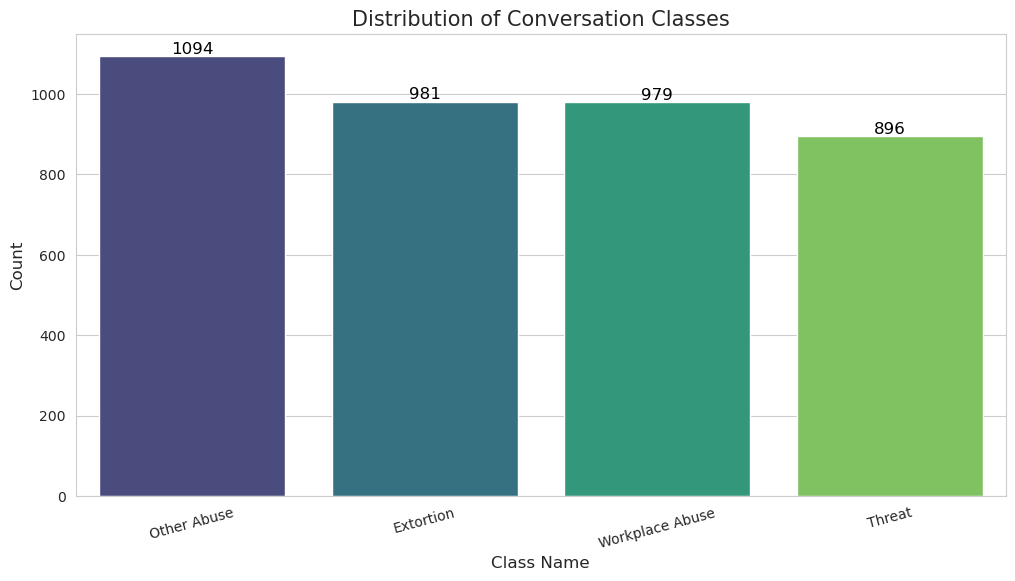

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
train_data = pd.read_csv("data/train.csv")

# 2. 한글 클래스명을 영어로 바꾸는 딕셔너리 생성
# (에러 로그에 찍힌 글자들을 바탕으로 매핑했습니다)
class_mapping = {
    '협박 대화': 'Threat',
    '갈취 대화': 'Extortion',
    '직장 내 괴롭힘 대화': 'Workplace Abuse',
    '기타 괴롭힘 대화': 'Other Abuse',
}

# 'class_en'이라는 새로운 영어 열 생성
train_data['class_en'] = train_data['class'].replace(class_mapping)

# 3. 빈도 및 비율 계산 (영어 열 기준)
class_counts = train_data['class_en'].value_counts()
class_relative = train_data['class_en'].value_counts(normalize=True) * 100

print("--- [Class Distribution] ---")
for idx, (count, rel) in enumerate(zip(class_counts, class_relative)):
    print(f"{class_counts.index[idx]:<20}: {count} ({rel:.2f}%)")

# 4. 시각화
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid") 

# x축에 class_en 사용
ax = sns.barplot(
    x=class_counts.index, 
    y=class_counts.values, 
    palette='viridis', 
    hue=class_counts.index, 
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribution of Conversation Classes', fontsize=15)
plt.xlabel('Class Name', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=15) # 글씨가 길면 살짝 기울여서 안 겹치게
plt.show()

#### 텍스트 통계

--- [Average Text Statistics by Class] ---
                 char_count  turn_count
class_en                               
Extortion            216.19       10.49
Other Abuse          210.08       10.21
Threat               246.07       10.35
Workplace Abuse      237.56       10.39
----------------------------------------


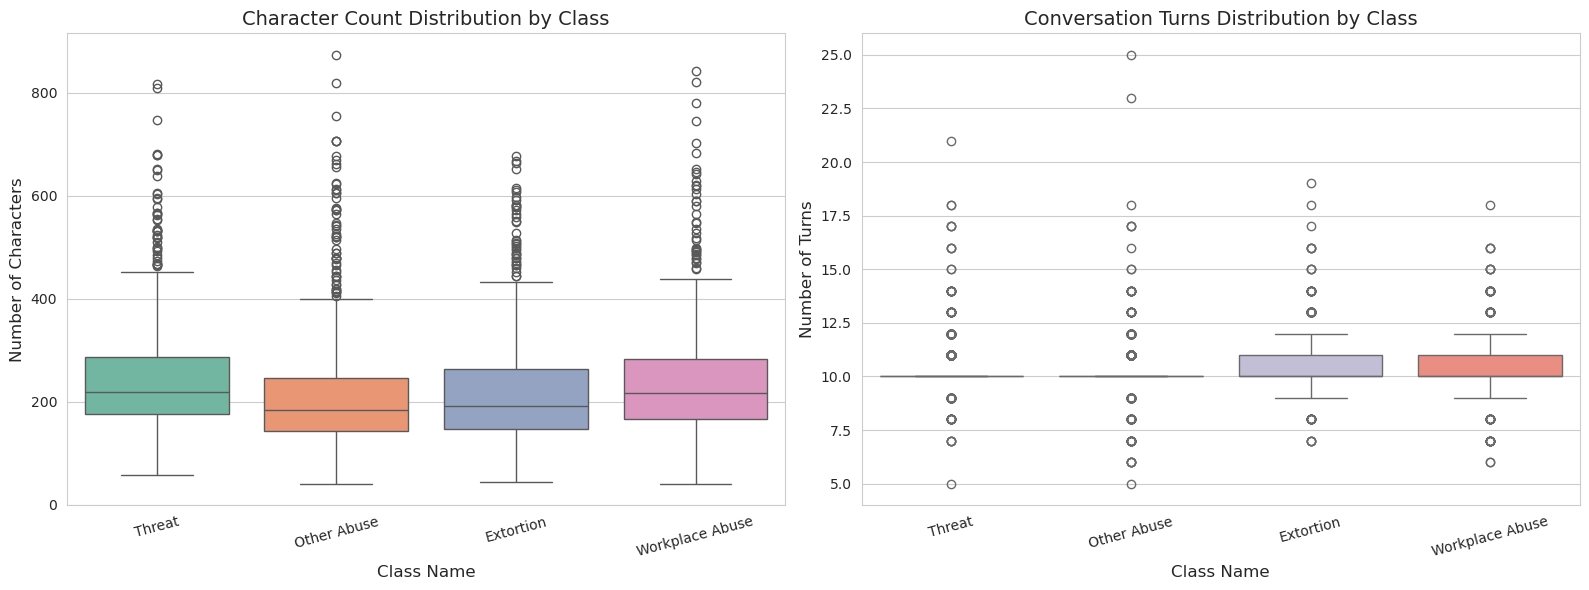

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 텍스트 통계 파생변수 생성
# 글자 수 (공백 및 특수기호 포함 전체 길이)
train_data['char_count'] = train_data['conversation'].apply(lambda x: len(str(x)))

# 대화 턴 수 ('\n'의 개수를 세고 + 1을 하면 총 대화 횟수가 됨)
train_data['turn_count'] = train_data['conversation'].apply(lambda x: str(x).count('\n') + 1)

# 2. 클래스별 평균 통계 수치 출력
print("--- [Average Text Statistics by Class] ---")
class_stats = train_data.groupby('class_en')[['char_count', 'turn_count']].mean().round(2)
print(class_stats)
print("-" * 40)

# 3. 시각화 (박스플롯으로 4개 클래스 한눈에 비교)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("whitegrid")

# 그래프 1: 클래스별 글자 수(Character Count) 분포
sns.boxplot(
    data=train_data, x='class_en', y='char_count', 
    palette='Set2', hue='class_en', legend=False, ax=axes[0]
)
axes[0].set_title('Character Count Distribution by Class', fontsize=14)
axes[0].set_xlabel('Class Name', fontsize=12)
axes[0].set_ylabel('Number of Characters', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)

# 그래프 2: 클래스별 대화 턴 수(Turn Count) 분포
sns.boxplot(
    data=train_data, x='class_en', y='turn_count', 
    palette='Set3', hue='class_en', legend=False, ax=axes[1]
)
axes[1].set_title('Conversation Turns Distribution by Class', fontsize=14)
axes[1].set_xlabel('Class Name', fontsize=12)
axes[1].set_ylabel('Number of Turns', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

#### 자주 나타나는 단어

In [52]:
# 클래스별로 자주 등장하는 단어 상위 10개 뽑기 함수
def get_top_words(df, class_name, n=10):
    # 해당 클래스의 대화 내용만 모으기
    text_data = df[df['class'] == class_name]['conversation']
    
    # 모든 문장을 띄어쓰기 기준으로 나누어 하나의 리스트로 만들기
    words = []
    for text in text_data:
        # \n 같은 특수기호를 공백으로 바꾸고 분리
        clean_text = text.replace('\n', ' ')
        words.extend(clean_text.split())
    
    # 단어 빈도 카운트
    word_counts = Counter(words)
    return word_counts.most_common(n)

# 전체 클래스 목록
classes = train_data['class'].unique()

print("=== 클래스별 가장 자주 등장하는 단어 Top 10 ===")
for c in classes:
    print(f"\n[{c}]")
    top_words = get_top_words(train_data, c, 10)
    for word, count in top_words:
        print(f"'{word}': {count}번")

=== 클래스별 가장 자주 등장하는 단어 Top 10 ===

[협박 대화]
'내가': 918번
'너': 857번
'다': 436번
'왜': 409번
'나': 358번
'제발': 343번
'내': 337번
'지금': 333번
'이': 309번
'진짜': 303번

[기타 괴롭힘 대화]
'너': 931번
'야': 662번
'내가': 626번
'왜': 584번
'아': 523번
'좀': 507번
'나': 435번
'진짜': 408번
'아니': 333번
'그냥': 308번

[갈취 대화]
'돈': 761번
'내가': 700번
'너': 660번
'나': 561번
'좀': 544번
'야': 465번
'다': 401번
'진짜': 380번
'아': 369번
'그럼': 361번

[직장 내 괴롭힘 대화]
'내가': 531번
'죄송합니다.': 495번
'좀': 474번
'네': 393번
'아': 389번
'제가': 378번
'네?': 364번
'아니': 356번
'너': 331번
'지금': 318번


#### 일반대화 생성 후 데이터 합치기

일반 대화 생성은 기존 데이터의 분포, 텍스트 길이 등을 고려

In [68]:
# 1. 데이터 경로 설정
train_data_path = "data/train.csv"
normal_data_path = "normal_conversations/normal_conversations.csv"

# 2. 데이터 불러오기
train_data = pd.read_csv(train_data_path)
normal_data = pd.read_csv(normal_data_path)

# 3. 추가 데이터 전처리: class 열을 '일반대화'로 통일
normal_data['class'] = '일반 대화'

# 4. 데이터 합치기 (기본 train 데이터 아래에 일반대화 추가)
# ignore_index=True를 사용해 판다스 자체 인덱스를 우선 초기화합니다.
total_train_data = pd.concat([train_data, normal_data], ignore_index=True)

# 5. [중요] idx 열 재정렬
# 기존의 꼬인 'idx' 열을 삭제합니다.
if 'idx' in total_train_data.columns:
    total_train_data = total_train_data.drop(columns=['idx'])

# 새로운 0부터 시작하는 인덱스를 'idx' 열로 맨 앞에 삽입합니다.
total_train_data.insert(0, 'idx', range(len(total_train_data)))

# 6. 결과 확인
print(f"✅ 병합 완료!")
print(f"전체 데이터 개수: {len(total_train_data)}개")
print(f"데이터 컬럼: {total_train_data.columns.tolist()}")
# 마지막 5행을 출력하여 '일반대화'가 잘 들어갔는지 확인합니다.
total_train_data.tail()

✅ 병합 완료!
전체 데이터 개수: 4950개
데이터 컬럼: ['idx', 'class', 'conversation']


,idx,class,conversation
4945,4945,일반 대화,비가 며칠째 계속 내리네. 끈적거려서 기분 완전 별로야.\n제습기 틀어도 뽀송해지지가 않네. 빨리 장마 끝났으면.\n비 오니까 파전에 막걸리 땡겨. 오늘 퇴근하고 한잔 어때?\n파전 완전 좋지! 비 오는 날엔 기름진 거 먹어줘야 해.\n주말에 비 온다는 소식 있던데? 기상청 예보 다시 확인해봐.\n콜! 늦으면 자리 꽉 차니까 퇴근하자마자 엄청 달려야 해.\n내가 5분 일찍 나가서 미리 자리 잡고 주문할 테니까 와.\n오늘 저녁엔 삼겹살 구워서 목에 낀 먼지 좀 내려보내야지.\n삼겹살 좋지. 핑계 훌륭하다. 맛있게 먹고 먼지 싹 내려.\n그것도 좋은 플랜이네. 날씨 어떻게 되나 같이 지켜보자!
4946,4946,일반 대화,오늘 하늘 맑은 거 봤어? 구름 한 점 없고 진짜 가을 하늘.\n아침에 출근할 때 보니까 기분 좋더라. 막 놀러 가고 싶고.\n이런 날은 집에 박혀서 공기청정기 풀가동하고 있어야 해.\n주말까지 이 날씨가 계속 유지되어야 할 텐데 걱정이네.\n핫팩도 챙겨. 요새 감기 걸리면 병원 가기도 힘드니까.\n비 오는 건 싫지만 미세먼지 없어지면 환영이야 다행이다.\n좋아. 뜨끈한 국밥 한 그릇 먹으면 몸이 싹 녹을 것 같아.\n생각만 해도 좋다. 12시 땡 치면 바로 국밥집으로 뛰어가자.\n홈파티도 재밌지! 비 오면 빔프로젝터 들고 너네 집 갈게.\n그것도 좋은 플랜이네. 날씨 어떻게 되나 같이 지켜보자!
4947,4947,일반 대화,비가 며칠째 계속 내리네. 끈적거려서 기분 완전 별로야.\n나도 패딩 입을까 하다가 코트 입었는데 완전 후회 중이야.\n이런 날씨엔 한강 가서 돗자리 깔고 누워있어야 하는데 휴.\n내일도 계속 공기 안 좋대? 뉴스에서 혹시 뭐라고 하던?\n막걸리는 내가 살게! 저번에 갔던 그 전집으로 가면 되겠다.\n헐 진짜? 주말에 캠핑 예약 다 해놨는데 제발 아니었으면.\n비 오고 나면 또 추워질 테니까 따뜻하게 챙겨 입어야겠다.\n그랬으면 좋겠다. 만약 비 오면 집에서 홈파티나 해야지 뭐.\n조심히 오고 비 많이 오니까 우산 튼튼한 걸로 잘 챙겨 와.\n그것도 좋은 플랜이네. 날씨 어떻게 되나 같이 지켜보자!
4948,4948,일반 대화,오늘 하늘 맑은 거 봤어? 구름 한 점 없고 진짜 가을 하늘.\n아침에 출근할 때 보니까 기분 좋더라. 막 놀러 가고 싶고.\n이런 날씨엔 한강 가서 돗자리 깔고 누워있어야 하는데 휴.\n주말까지 이 날씨가 계속 유지되어야 할 텐데 걱정이네.\n내일 오후부터는 비 오면서 씻겨 내려간대. 완전 다행이지.\n헐 진짜? 주말에 캠핑 예약 다 해놨는데 제발 아니었으면.\n내가 5분 일찍 나가서 미리 자리 잡고 주문할 테니까 와.\n생각만 해도 좋다. 12시 땡 치면 바로 국밥집으로 뛰어가자.\n홈파티도 재밌지! 비 오면 빔프로젝터 들고 너네 집 갈게.\n내일 맑은 하늘 볼 수 있기를 기대하면서 오늘 푹 쉬자!
4949,4949,일반 대화,비가 며칠째 계속 내리네. 끈적거려서 기분 완전 별로야.\n나도 패딩 입을까 하다가 코트 입었는데 완전 후회 중이야.\n이런 날씨엔 한강 가서 돗자리 깔고 누워있어야 하는데 휴.\n내일도 계속 공기 안 좋대? 뉴스에서 혹시 뭐라고 하던?\n내일 오후부터는 비 오면서 씻겨 내려간대. 완전 다행이지.\n너도 감기 조심해. 이따 점심엔 따뜻한 국물 있는 거 먹자.\n비 오고 나면 또 추워질 테니까 따뜻하게 챙겨 입어야겠다.\n그랬으면 좋겠다. 만약 비 오면 집에서 홈파티나 해야지 뭐.\n내가 미리 메뉴도 정해놨어. 수육 국밥으로 통일하는 거콜?\n알았어 맛있는 파전 먹을 생각하면서 남은 시간 버텨본다!


#### label 통일

In [69]:
# 1. 라벨 매핑 함수 정의 (사용자님의 기존 로직 반영)
def get_label(class_name):
    if '협박' in class_name:
        return 0
    elif '갈취' in class_name:
        return 1
    elif '직장 내 괴롭힘' in class_name:
        return 2
    elif '기타 괴롭힘' in class_name:
        return 3
    else: # 일반대화 등
        return 4

# 2. label 데이터 생성
labels = total_train_data['class'].apply(get_label)

# 3. 원하는 위치(class와 conversation 사이)에 열 삽입
# 현재 열 순서가 [idx, class, conversation] 이라면, 
# index 2 위치에 넣으면 [idx, class, label, conversation] 순서가 됩니다.
if 'label' in total_train_data.columns:
    total_train_data = total_train_data.drop(columns=['label']) # 중복 방지

total_train_data.insert(2, 'label', labels)

# 4. 결과 확인
print("✅ label 열 생성 및 삽입 완료!")
display(total_train_data.head())

# 각 라벨별로 데이터가 몇 개씩 들어갔는지 확인해볼까요?
print("\n[라벨별 데이터 분포]")
print(total_train_data['label'].value_counts().sort_index())

✅ label 열 생성 및 삽입 완료!


,idx,class,label,conversation
0,0,협박 대화,0,지금 너 스스로를 죽여달라고 애원하는 것인가?\n 아닙니다. 죄송합니다.\n 죽을 거면 혼자 죽지 우리까지 사건에 휘말리게 해? 진짜 죽여버리고 싶게.\n 정말 잘못했습니다.\n 너가 선택해. 너가 죽을래 네 가족을 죽여줄까.\n 죄송합니다. 정말 잘못했습니다.\n 너에게는 선택권이 없어. 선택 못한다면 너와 네 가족까지 모조리 죽여버릴거야.\n 선택 못하겠습니다. 한번만 도와주세요.\n 그냥 다 죽여버려야겠군. 이의 없지?\n 제발 도와주세요.
1,1,협박 대화,0,길동경찰서입니다.\n9시 40분 마트에 폭발물을 설치할거다.\n네?\n똑바로 들어 한번만 더 얘기한다.\n장난전화 걸지 마시죠. \n9시 40분 마트에 폭발물이 터지면 다 죽는거야. \n장난전화는 업무방해죄에 해당됩니다.\n판단은 너에게 달려있다. 길동경찰서에도 폭발물 터지면 꽤나 재미있겠지.\n선생님 진정하세요.\n난 이야기했어. 경고했다는 말이야.
2,2,기타 괴롭힘 대화,3,너 되게 귀여운거 알지? 나보다 작은 남자는 첨봤어.\n그만해. 니들 놀리는거 재미없어.\n지영아 너가 키 160이지? 그럼 재는 160도 안돼는거네?\n너 군대도 안가고 좋겠다.\n니들이 나 작은데 보태준거 있냐?\n난쟁이들도 장가가고하던데. 너도 희망을 가져봐 \n더이상 하지마라. \n그 키크는 수술도 있대잖아? 니네 엄마는 그거 안해주디?\n나람 해줬어. 저 키로 어찌살아.\n제발 그만 괴롭히라고!
3,3,갈취 대화,1,어이 거기\n예??\n너 말이야 너. 이리 오라고\n무슨 일.\n너 옷 좋아보인다?\n얘 돈 좀 있나봐\n아니에요.돈 없어요\n뒤져서 나오면 넌 죽는다\n오늘 피시방 콜?\n콜. 마지막 기회다. 있는거 다 내놔\n정말 없어요
4,4,갈취 대화,1,저기요 혹시 날이 너무 뜨겁잖아요? 저희 회사에서 이 선크림 파는데 한 번 손등에 발라보실래요?\n아 진짜요? 안 그래도 선크림 필요해서 알아보던 중인데 한 번 발라 볼게요!\n여기 한 번 발라보세요. 진짜 성분도 좋고 다 좋아요.\n음. 성분이 좋다고 하셔서 좋은거 같기는 한데 제 피부에 맞지 않나봐요. 피부가 따끔거리네요.\n이번에 진짜 열심히 연구해서 만든건데 피부가 많이 예민하신가봐요.\n네 많이 예민해요. 그럼 많이 파시고 안녕히 계세요.\n아니 저기요 돈 안내요?\n네? 발라보는것도 돈 내야 하나요?\n그럼 이거 누구한테 팔아요? 당신이 바른거를?\n아니 먼저 발라 보시라고 하셨잖아요. 먼저 권유해놓고 사라고 강매하는거 갈취인거 몰라요?\n내가 안 사도 된다고 말 한 적 있어? 그것도 모르고 바른걸 누구 탓 하나? 빨리 사 당신이 바른거 당신이 사야지\n진짜 어이가 없어서 다른 사람들한텐 이렇게 갈취하지마세요. 화딱지나네



[라벨별 데이터 분포]
label
0     896
1     981
2     979
3    1094
4    1000
Name: count, dtype: int64


##### 파일 저장

In [70]:
save_path = "train_combined.csv"
total_train_data.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"✅ 저장이 완료되었습니다: {save_path}")

✅ 저장이 완료되었습니다: train_combined.csv


--- [Class Distribution] ---
Other Abuse         : 1094 (22.10%)
Normal Conversation : 1000 (20.20%)
Extortion           : 981 (19.82%)
Workplace Abuse     : 979 (19.78%)
Threat              : 896 (18.10%)


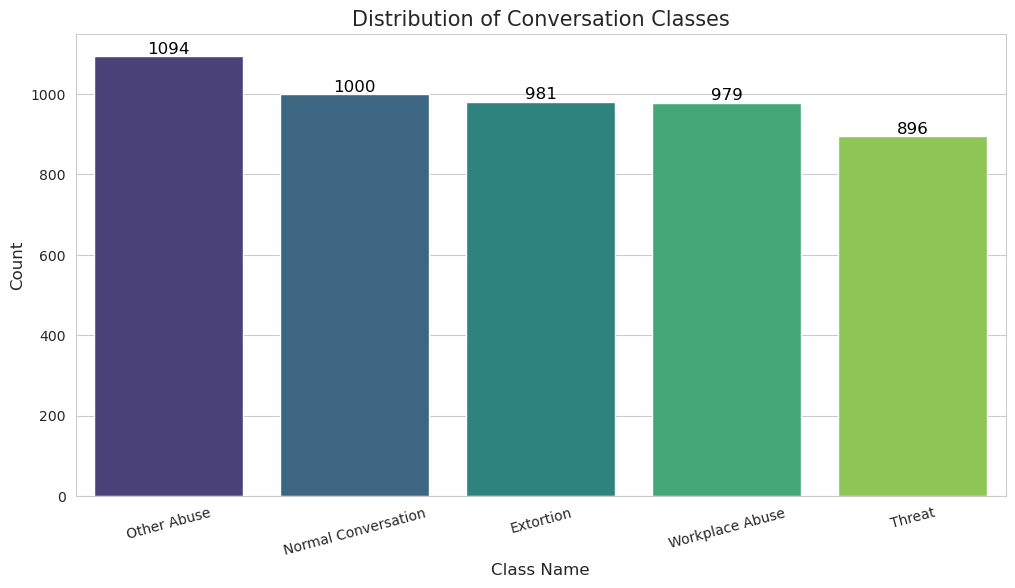

In [76]:
train_combined_path ="normal_conversations/train_combined.csv"
train_combined = pd.read_csv(train_combined_path)

# 2. 한글 클래스명을 영어로 바꾸는 딕셔너리 생성
# (에러 로그에 찍힌 글자들을 바탕으로 매핑했습니다)
class_mapping = {
    '협박 대화': 'Threat',
    '갈취 대화': 'Extortion',
    '직장 내 괴롭힘 대화': 'Workplace Abuse',
    '기타 괴롭힘 대화': 'Other Abuse',
    '일반 대화': 'Normal Conversation'
}

# 'class_en'이라는 새로운 영어 열 생성
train_combined['class_en'] = train_combined['class'].replace(class_mapping)

# 3. 빈도 및 비율 계산 (영어 열 기준)
class_counts = train_combined['class_en'].value_counts()
class_relative = train_combined['class_en'].value_counts(normalize=True) * 100

print("--- [Class Distribution] ---")
for idx, (count, rel) in enumerate(zip(class_counts, class_relative)):
    print(f"{class_counts.index[idx]:<20}: {count} ({rel:.2f}%)")

# 4. 시각화
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid") 

# x축에 class_en 사용
ax = sns.barplot(
    x=class_counts.index, 
    y=class_counts.values, 
    palette='viridis', 
    hue=class_counts.index, 
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribution of Conversation Classes', fontsize=15)
plt.xlabel('Class Name', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=15) # 글씨가 길면 살짝 기울여서 안 겹치게
plt.show()

--- [Average Text Statistics by Class] ---
                     char_count  turn_count
class_en                                   
Extortion                216.19       10.49
Normal Conversation      298.43       10.00
Other Abuse              210.08       10.21
Threat                   246.07       10.35
Workplace Abuse          237.56       10.39
----------------------------------------


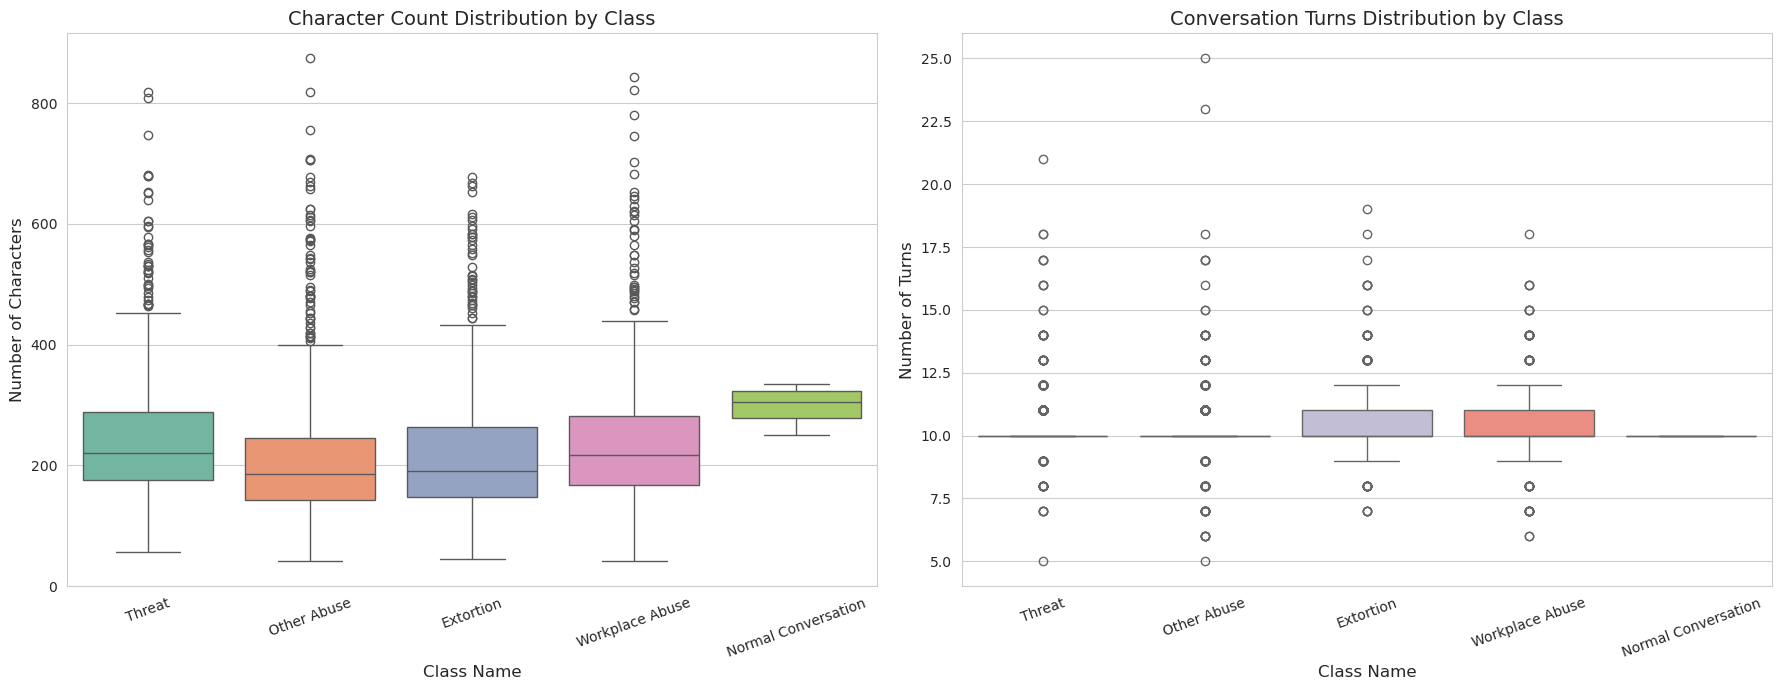

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 텍스트 통계 파생변수 생성 (train_combined 변수 사용)
# 글자 수 (공백 및 특수기호 포함 전체 길이)
train_combined['char_count'] = train_combined['conversation'].apply(lambda x: len(str(x)))

# 대화 턴 수 ('\n'의 개수를 세고 + 1)
train_combined['turn_count'] = train_combined['conversation'].apply(lambda x: str(x).count('\n') + 1)

# 2. 클래스별 평균 통계 수치 출력
print("--- [Average Text Statistics by Class] ---")
# 이제 class_en에 'Normal Conversation'이 포함되어 있으므로 함께 출력됩니다.
class_stats = train_combined.groupby('class_en')[['char_count', 'turn_count']].mean().round(2)
print(class_stats)
print("-" * 40)

# 3. 시각화 (박스플롯으로 5개 클래스 비교)
fig, axes = plt.subplots(1, 2, figsize=(18, 7)) # 가로 길이를 조금 더 늘렸습니다.
sns.set_style("whitegrid")

# 그래프 1: 클래스별 글자 수(Character Count) 분포
sns.boxplot(
    data=train_combined, x='class_en', y='char_count', 
    palette='Set2', hue='class_en', legend=False, ax=axes[0]
)
axes[0].set_title('Character Count Distribution by Class', fontsize=14)
axes[0].set_xlabel('Class Name', fontsize=12)
axes[0].set_ylabel('Number of Characters', fontsize=12)
axes[0].tick_params(axis='x', rotation=20) # 글자가 겹치지 않게 회전값 조정

# 그래프 2: 클래스별 대화 턴 수(Turn Count) 분포
sns.boxplot(
    data=train_combined, x='class_en', y='turn_count', 
    palette='Set3', hue='class_en', legend=False, ax=axes[1]
)
axes[1].set_title('Conversation Turns Distribution by Class', fontsize=14)
axes[1].set_xlabel('Class Name', fontsize=12)
axes[1].set_ylabel('Number of Turns', fontsize=12)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [82]:
# 클래스별로 자주 등장하는 단어 상위 10개 뽑기 함수
def get_top_words(df, class_name, n=10):
    # 해당 클래스의 대화 내용만 모으기
    text_data = df[df['class'] == class_name]['conversation']
    
    # 모든 문장을 띄어쓰기 기준으로 나누어 하나의 리스트로 만들기
    words = []
    for text in text_data:
        # \n 같은 특수기호를 공백으로 바꾸고 분리
        clean_text = text.replace('\n', ' ')
        words.extend(clean_text.split())
    
    # 단어 빈도 카운트
    word_counts = Counter(words)
    return word_counts.most_common(n)

# 전체 클래스 목록
classes = train_combined['class'].unique()

print("=== 클래스별 가장 자주 등장하는 단어 Top 10 ===")
for c in classes:
    print(f"\n[{c}]")
    top_words = get_top_words(train_combined, c, 10)
    for word, count in top_words:
        print(f"'{word}': {count}번")

=== 클래스별 가장 자주 등장하는 단어 Top 10 ===

[협박 대화]
'내가': 918번
'너': 857번
'다': 436번
'왜': 409번
'나': 358번
'제발': 343번
'내': 337번
'지금': 333번
'이': 309번
'진짜': 303번

[기타 괴롭힘 대화]
'너': 931번
'야': 662번
'내가': 626번
'왜': 584번
'아': 523번
'좀': 507번
'나': 435번
'진짜': 408번
'아니': 333번
'그냥': 308번

[갈취 대화]
'돈': 761번
'내가': 700번
'너': 660번
'나': 561번
'좀': 544번
'야': 465번
'다': 401번
'진짜': 380번
'아': 369번
'그럼': 361번

[직장 내 괴롭힘 대화]
'내가': 531번
'죄송합니다.': 495번
'좀': 474번
'네': 393번
'아': 389번
'제가': 378번
'네?': 364번
'아니': 356번
'너': 331번
'지금': 318번

[일반 대화]
'완전': 1027번
'내가': 950번
'오늘': 834번
'거': 765번
'먹고': 696번
'진짜': 665번
'빨리': 663번
'안': 657번
'너무': 622번
'비': 619번
